#### 🎯 Objective

Build a Customer Segmentation Model using unsupervised learning to group customers based on purchasing behavior.

💼 Business Use Case

Identify high-value customers (VIP)

Detect inactive/lost customers

Enable targeted marketing campaigns

Improve customer retention

❓ Key Questions

Who are the most valuable customers?

Which customers are likely to churn?

Can we group customers based on behavior?

In [5]:
# import the Library as per requirements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

In [8]:
df.shape

(541909, 8)

In [9]:
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
170827,551342,22518,CHILDS GARDEN BRUSH BLUE,6,2011-04-28 08:34:00,2.10,16099.0,United Kingdom
283124,561693,22969,HOMEMADE JAM SCENTED CANDLES,12,2011-07-29 09:48:00,1.45,15120.0,United Kingdom
322178,565231,20727,LUNCH BAG BLACK SKULL.,1,2011-09-02 09:26:00,4.13,NaN,United Kingdom
149676,549298,22611,VINTAGE UNION JACK SHOPPING BAG,3,2011-04-08 08:20:00,4.95,13015.0,United Kingdom
104254,545157,21169,YOU'RE CONFUSING ME METAL SIGN,12,2011-02-28 13:27:00,1.69,14239.0,United Kingdom
109459,545638,22980,PANTRY SCRUBBING BRUSH,2,2011-03-04 12:26:00,1.65,13113.0,United Kingdom
209921,555275,90119,METALIC LEAVES BAG CHARMS,1,2011-06-01 17:18:00,2.46,NaN,United Kingdom
232206,557309,22605,WOODEN CROQUET GARDEN SET,1,2011-06-19 15:15:00,14.95,16493.0,United Kingdom
205116,554712,22199,FRYING PAN RED RETROSPOT,8,2011-05-26 10:43:00,4.25,16873.0,United Kingdom
287176,562087,84950,ASSORTED COLOUR T-LIGHT HOLDER,12,2011-08-02 12:31:00,0.65,14606.0,United Kingdom


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


In [12]:
# check the null value 
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
df["CustomerID"].sample(20)

359835    16771.0
493060    12748.0
395952    16670.0
2688          NaN
504567    13546.0
426196    17609.0
239793        NaN
452720    16655.0
140834    12782.0
256852        NaN
212826        NaN
16888         NaN
155467    13221.0
435951    14911.0
281822    18151.0
436129    17611.0
535142    17449.0
128677    15998.0
334815    16523.0
240751    16003.0
Name: CustomerID, dtype: float64

In [19]:
# The Percentage View
null_percentage = (df.isnull().sum()/len(df)) * 100
print("null percentage\n",null_percentage)

null percentage
 InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


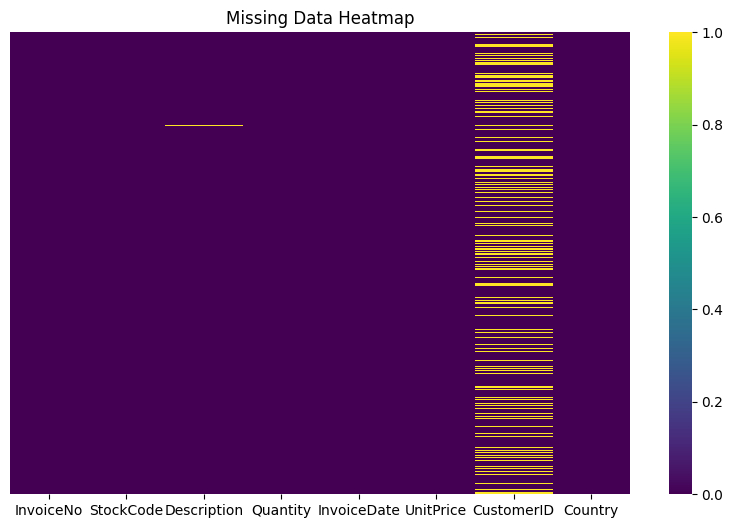

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),yticklabels=False,cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

In [ ]:
# Drop rows where CustomerID is missing (Crucial for Segmentation)
df.dropna(subset=['CustomerID'], inplace=True)

In [21]:
# Convert CustomerID to integer (it often loads as float)
df['CustomerID'] = df['CustomerID'].astype(int)

In [22]:
# Handle the Description of the missing value we fill them with "Unknown"
df["Description"] = df["Description"].fillna("Unknown")

In [23]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [26]:
df.shape

(406829, 8)

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  int32         
 7   Country      406829 non-null  str           
dtypes: datetime64[us](1), float64(1), int32(1), int64(1), object(3), str(1)
memory usage: 26.4+ MB


In [22]:
df.shape

(406829, 8)

In [23]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

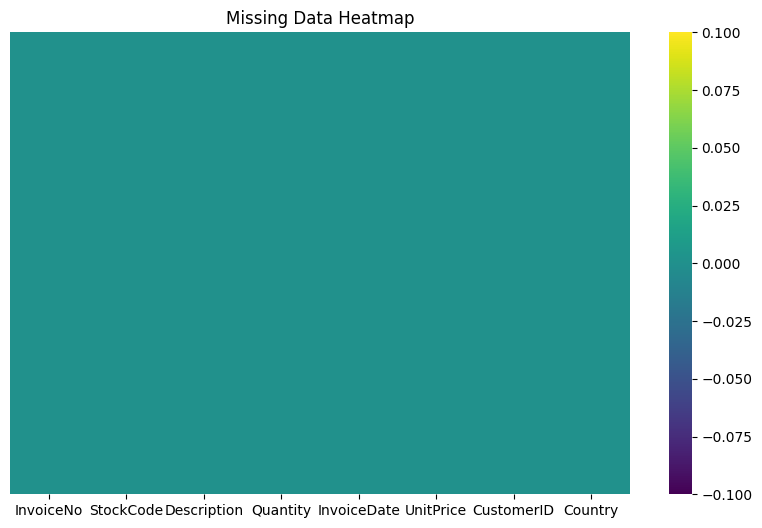

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),yticklabels=False,cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

In [29]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [32]:
neg_count = (df["Quantity"] < 0).sum()
neg_count

8905

In [33]:
# Remove Returns (negative quantity)
df = df[df["Quantity"] > 0]

In [35]:
# Remove Invalid Prices
df = df[df["UnitPrice"] > 0]

In [38]:
df.info()

<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int32         
 7   Country      397884 non-null  str           
dtypes: datetime64[us](1), float64(1), int32(1), int64(1), object(3), str(1)
memory usage: 25.8+ MB


In [40]:
print("clean data successfully")
print("Let's Start EDA")

clean data successfully
Let's Start EDA


#### EDA

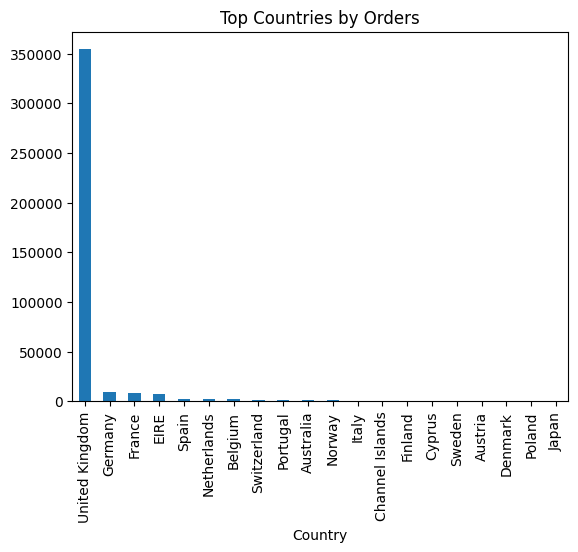

In [49]:
# Top Countries
df["Country"].value_counts().head(20).sort_values(ascending=False).plot(kind="bar")
plt.title("Top Countries by Orders")
plt.show()

* The UK is the primary revenue-driving region and should be the main focus for marketing and customer retention strategies.

In [50]:
# Total Counties
df["Country"].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Finland',
              'Austria',               'Greece',            'Singapore',
              'Lebanon', 'United Arab Emirates',               'Israel',
         'Saudi Arabia',       'Czech Republic',               'Canada',
          'Unspecified',               'Brazil',                  'USA',
   'European Community',              'Bahrain',                'Malta',
                  'RSA']
Length: 37, dtype: str

Revenue Distribution

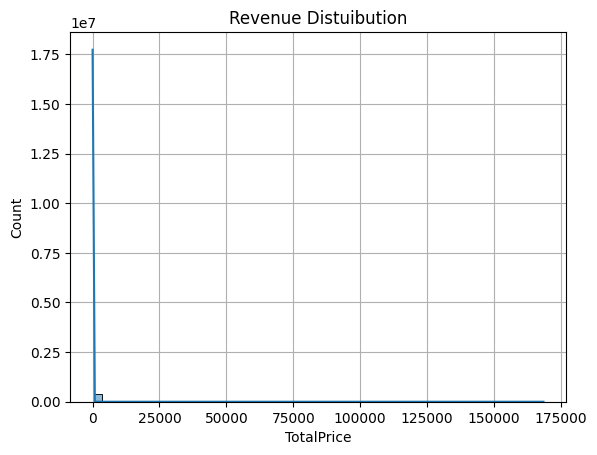

In [100]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

sns.histplot(df["TotalPrice"], bins=50,kde=True)
plt.grid()
plt.title("Revenue Distuibution")
plt.show()

In [103]:
# Calculate Skewness and Kurtosis
print(f"Skewness: {df['TotalPrice'].skew():.2f}")
print(f"Kurtosis: {df['TotalPrice'].kurt():.2f}")

Skewness: 451.44
Kurtosis: 232155.12


* "The initial features exhibited extreme Positive Skewness (451.44) and High Kurtosis (232,155.12), indicating a customer base dominated by a small number of extreme high-value outliers. To prevent these 'Whale' customers from biasing the K-Means distance calculations, a Log Transformation was applied to normalize the distribution and ensure the model identifies meaningful segments across the entire customer base."

Sales Over Time


In [97]:
df['InvoiceDate'].unique()

<DatetimeArray>
['2010-12-01 08:26:00', '2010-12-01 08:28:00', '2010-12-01 08:34:00',
 '2010-12-01 08:35:00', '2010-12-01 08:45:00', '2010-12-01 09:00:00',
 '2010-12-01 09:01:00', '2010-12-01 09:02:00', '2010-12-01 09:09:00',
 '2010-12-01 09:32:00',
 ...
 '2011-12-09 12:09:00', '2011-12-09 12:16:00', '2011-12-09 12:19:00',
 '2011-12-09 12:20:00', '2011-12-09 12:21:00', '2011-12-09 12:23:00',
 '2011-12-09 12:25:00', '2011-12-09 12:31:00', '2011-12-09 12:49:00',
 '2011-12-09 12:50:00']
Length: 17282, dtype: datetime64[us]

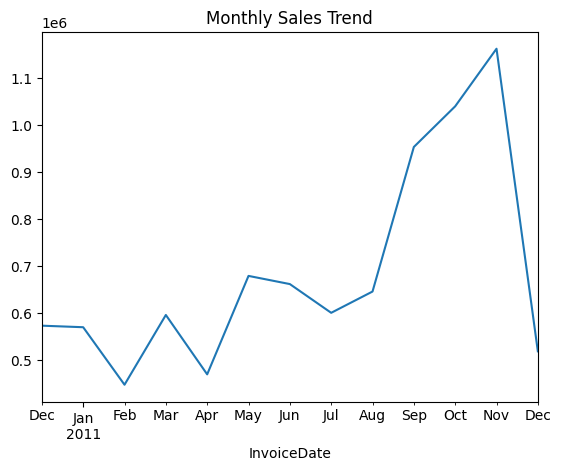

In [58]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.set_index('InvoiceDate')['TotalPrice'].resample('ME').sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

##### Revenue Maximization Window
* September → November = High revenue period

* Strategy:

* Increase inventory
* Launch major campaigns
* Offer premium products

##### Low Sales Period (Opportunity)
* February, April → weak months

* Strategy:

* Discounts
* Promotions
* Customer re-engagement

Conclusion

* "The monthly sales analysis shows a clear seasonal trend with a strong revenue spike in the last quarter, particularly in November. This suggests that the business should focus its marketing and inventory strategies around this peak period while using targeted campaigns to boost sales during low-performing months."

#### Feature Engineering

In [72]:
# Create RFM feature

import datetime as dt
today = df["InvoiceDate"].max() + dt.timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate":lambda x: (today - x.max()).days,
    "InvoiceNo": "count",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,182,4310.00
12348,75,31,1797.24
12349,19,73,1757.55
12350,310,17,334.40


| Cluster | Recency | Frequency | Monetary | Meaning           |
| ------- | ------- | --------- | -------- | ----------------- |
| 0       | Low     | High      | High     | 🟢 VIP Customers  |
| 1       | High    | Low       | Low      | 🔴 Lost Customers |
| 2       | Medium  | Medium    | Medium   | 🟡 Regular        |
| 3       | Low     | Low       | Medium   | 🔵 New Customers  |


* "I used RFM analysis to transform transactional data into meaningful customer behavior features. Recency captures how recently a customer engaged, Frequency measures purchase consistency, and Monetary reflects spending value. These features were then used for clustering to identify customer segments for targeted marketing."

#### Before(DF)

| CustomerID | Invoice | Item | Price |
| ---------- | ------- | ---- | ----- |
| 12347      | A001    | Pen  | 10    |
| 12347      | A002    | Book | 50    |

Same customer appears multiple times

#### AFTER RFM

| CustomerID | Recency | Frequency | Monetary |
| ---------- | ------- | --------- | -------- |
| 12347      | 2       | 182       | 4310     |

One row per customer

* 397,884 transactions
* Only 4,338 unique customers

* We transformed transactional data into customer-level behavioral data."

* "I aggregated transaction-level data into customer-level features using RFM analysis, reducing data from ~398K transactions to ~4.3K unique customers for meaningful segmentation."

In [109]:
df["CustomerID"].sample(10)

250413    12839
231150    17204
147302    14606
188167    13451
187769    15544
345872    17750
426033    13566
250414    12839
361301    14096
421278    15791
Name: CustomerID, dtype: int32

In [85]:
# apply log Transformation
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])

1. Reduces Skewness
* Makes distribution more normal-like
2. Handles Outliers
* Extreme values no longer dominate
3. Improves Clustering
* Balanced clusters
* Better separation

* "Since the RFM features, especially Monetary, were highly skewed, I applied log transformation to reduce the effect of outliers and improve clustering performance."

In [113]:
rfm_log

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.789960,0.693147,11.253955
12347,1.098612,5.209486,8.368925
12348,4.330733,3.465736,7.494564
12349,2.995732,4.304065,7.472245
12350,5.739793,2.890372,5.815324
...,...,...,...
18280,5.631212,2.397895,5.201806
18281,5.204007,2.079442,4.404522
18282,2.197225,2.564949,5.187665


In [112]:
rfm

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,1,Regular Customers
12347,2,182,4310.00,2,VIP Customers
12348,75,31,1797.24,1,Regular Customers
12349,19,73,1757.55,1,Regular Customers
12350,310,17,334.40,3,Churned Customers
...,...,...,...,...,...
18280,278,10,180.60,3,Churned Customers
18281,181,7,80.82,3,Churned Customers
18282,8,12,178.05,0,Loyal Customers


#### Feature Scaling

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

## Model Building (Clustering)

In [115]:
from sklearn.cluster import KMeans

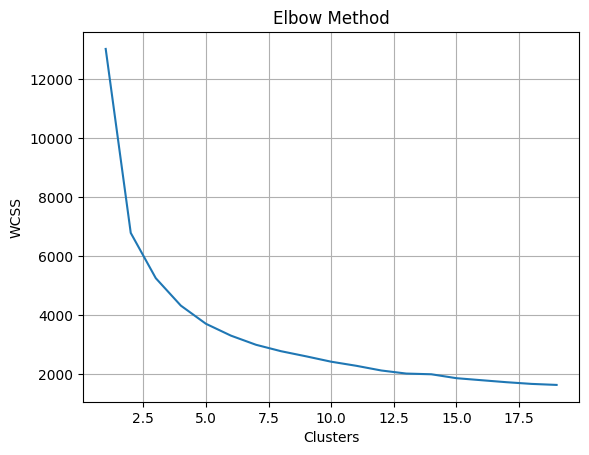

In [116]:
wcss = []

for i in range(1, 20):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 20), wcss)
plt.grid()
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()


In [117]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [119]:
# Evaluate
from sklearn.metrics import silhouette_score

print("silhouette Score: ",silhouette_score(rfm_scaled,kmeans.labels_))

silhouette Score:  0.3084370253634246


In [120]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,20.414352,37.123843,588.002535
1,94.341660,80.112812,1515.635587
2,12.845538,281.406178,6996.487941
3,187.991170,15.040471,299.881892


| Cluster | Recency | Frequency | Monetary | Meaning           |
| ------- | ------- | --------- | -------- | ----------------- |
| 0       | Low     | High      | High     | 🟢 VIP Customers  |
| 1       | High    | Low       | Low      | 🔴 Lost Customers |
| 2       | Medium  | Medium    | Medium   | 🟡 Regular        |
| 3       | Low     | Low       | Medium   | 🔵 New Customers  |


<Axes: xlabel='Recency', ylabel='Monetary'>

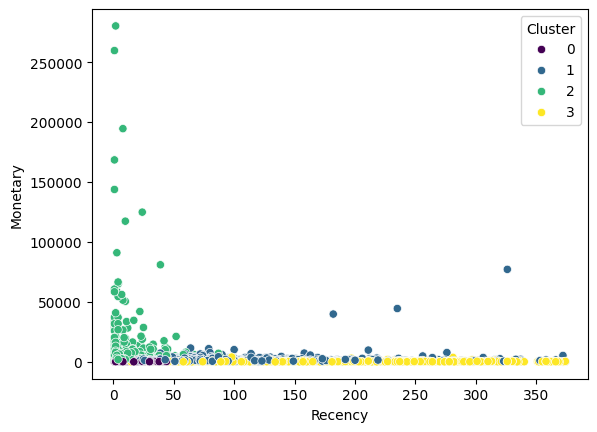

In [121]:
sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['Cluster'],
    palette='viridis'
)

In [122]:
cluster_names = {
    0: "Loyal Customers",
    1: "Regular Customers",
    2: "VIP Customers",
    3: "Churned Customers"
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

<Axes: xlabel='Cluster', ylabel='Monetary'>

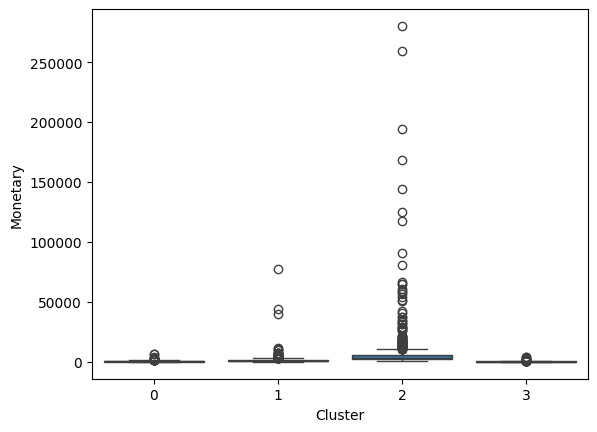

In [123]:
sns.boxplot(x='Cluster', y='Monetary', data=rfm)

| Segment | Recency | Frequency | Monetary | Business Value |
| ------- | ------- | --------- | -------- | -------------- |
| VIP     | Low     | High      | High     | 🔥 Highest     |
| Loyal   | Low     | High      | Medium   | 💪 Strong      |
| Regular | Medium  | Medium    | Low-Med  | ⚖️ Moderate    |
| Churned | High    | Low       | Low      | ⚠️ Low         |


# 🎯 FINAL CUSTOMER SEGMENTATION

---

## 🧠 1. VIP Customers 💰

### 📊 Characteristics:
- Low Recency → Recently active  
- High Frequency → Buy often  
- High Monetary → Spend a lot  

### 💼 Business Insight:
These customers contribute a large portion of total revenue.

### 🎯 Strategy:
- Premium offers  
- Early product access  
- Loyalty / VIP programs  

---

## 🔁 2. Loyal Customers

### 📊 Characteristics:
- Low Recency → Active  
- High Frequency → Frequent buyers  
- Medium Monetary  

### 💼 Business Insight:
Consistent customers with strong engagement.

### 🎯 Strategy:
- Upselling  
- Cross-selling  
- Reward programs  

---

## 📉 3. Regular Customers

### 📊 Characteristics:
- Medium Recency  
- Medium Frequency  
- Low–Medium Monetary  

### 💼 Business Insight:
Average customers with potential to grow.

### 🎯 Strategy:
- Personalized recommendations  
- Discounts on repeat purchases  

---

## 🚨 4. Churned Customers

### 📊 Characteristics:
- High Recency → Inactive  
- Low Frequency  
- Low Monetary  

### 💼 Business Insight:
These customers are at risk or already lost.

### 🎯 Strategy:
- Re-engagement campaigns  
- Discounts  
- Email marketing  

---

# apply DBSCAN

* KMeans → good for segmentation
* DBSCAN → good for anomaly detection (VIP/extreme customers) 

In [125]:
from sklearn.cluster import DBSCAN

In [126]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)


Check Clusters

In [127]:
rfm['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    4319
-1      19
Name: count, dtype: int64

* -1 = Noise (outliers)

<Axes: xlabel='Recency', ylabel='Monetary'>

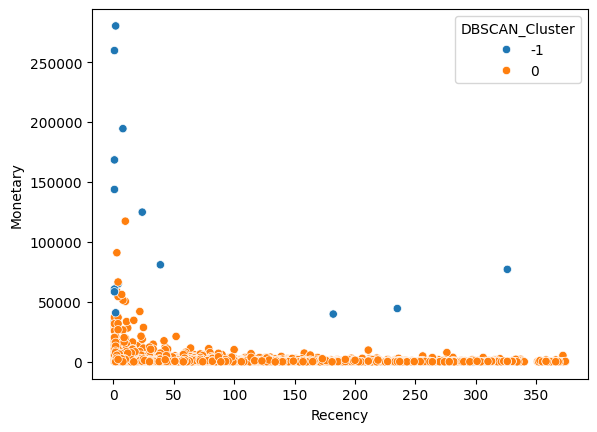

In [128]:
import seaborn as sns

sns.scatterplot(
    x=rfm['Recency'],
    y=rfm['Monetary'],
    hue=rfm['DBSCAN_Cluster'],
    palette='tab10'
)

Typical Outcome:

* Cluster(s)
* Normal customers grouped by density
* Noise (-1)
##### Outliers:
* Extremely high spenders
* Rare behavior

* These are:

* VIP customers
* Or potential fraud

| Aspect | KMeans | DBSCAN |
|------|--------|--------|
| Need to choose clusters | Yes (k) | No |
| Handles outliers | ❌ No | ✅ Yes |
| Works on skewed data | Needs preprocessing | Better |
| Interpretability | High | Medium |
| Best use case | Customer segmentation | Anomaly detection |

## Final Insights Section

### 📊 Final Insights

- Majority of customers are low-value with small transactions.
- A small segment of customers (VIP) contributes most of the revenue.
- Customer behavior is highly skewed, requiring log transformation.
- Sales show strong seasonality with peak in November.
- UK dominates the market, indicating geographic concentration.

###  Business Recommendations

- Focus on VIP customers with loyalty programs and premium offers.
- Target churned customers with re-engagement campaigns.
- Use upselling strategies for regular customers.
- Expand into international markets beyond the UK.
- Plan marketing campaigns around peak seasonal periods.

# 🤖 Model Comparison

- KMeans provided clear and interpretable customer segments.
- DBSCAN helped identify outliers and unusual customer behavior.
- KMeans is better suited for business segmentation.
- DBSCAN is useful for anomaly detection.

### Visualization

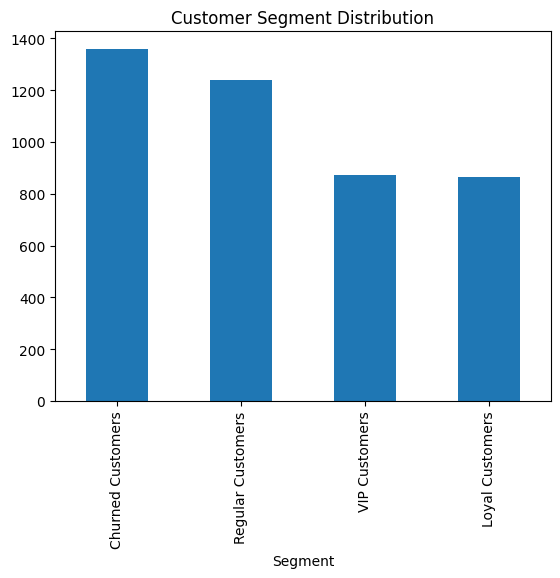

In [130]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.show()

# 🎯 Conclusion

This project successfully segmented customers using RFM analysis and KMeans clustering. The segmentation provides actionable insights for targeted marketing, customer retention, and revenue optimization. The addition of DBSCAN further enhanced the analysis by identifying outliers and high-value customers.